In [190]:
# Importing necessary libraries and defining fundamental statistical functions for our emission distributions (Gaussian/Laplace) and log-return calculations.

import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.io as pio
import time
import os

def gaussian(x, mean, std):
    return (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2)

def laplace(x, mean, scale):
    return (1 / (2 * scale)) * np.exp(-abs(x - mean) / scale)

def calculate_log_returns(data):
    return np.log(data / data.shift(1))

In [191]:
# This class handles the complex recursive initialization of the Hierarchical HMM architecture, including transition matrices, initial state probabilities ($\pi$), and termination probabilities across varying depths.

class InitHHMMFunctions:
    def __init__(self, n_sibs, data=None):
        self.n_sibs = n_sibs
        self.data = data

    def initialize_pi(self):
        pi = {}
        def recursive_initialize(depth=0, parent_idx=0):
            if depth == 0:
                pi[depth] = np.ones(self.n_sibs[0]) / self.n_sibs[0]
                for i in range(self.n_sibs[0]):
                    recursive_initialize(depth + 1, i)
            elif depth < len(self.n_sibs):
                if depth not in pi:
                    pi[depth] = {}
                num_states_current = self.n_sibs[depth]
                for j in range(num_states_current):
                    idx = parent_idx * num_states_current + j
                    pi[depth][parent_idx] = np.ones(self.n_sibs[depth]) / self.n_sibs[depth]
                    if depth + 1 < len(self.n_sibs):
                        recursive_initialize(depth + 1, idx)
        recursive_initialize()
        return pi

    def initialize_termination_probs(self):
        termination = {}
        def recursive_initialize(depth=0, parent_idx=0):
            if depth == 0:
                termination[depth] = np.ones(self.n_sibs[0]) * 0.1
                for i in range(self.n_sibs[0]):
                    recursive_initialize(depth + 1, i)
            elif depth < len(self.n_sibs) and depth != len(self.n_sibs) - 1:
                if depth not in termination:
                    termination[depth] = {}
                num_states_current = self.n_sibs[depth]
                for j in range(num_states_current):
                    idx = parent_idx * num_states_current + j
                    termination[depth][parent_idx] = np.ones(self.n_sibs[depth]) * 0.1
                    if depth + 1 < len(self.n_sibs):
                        recursive_initialize(depth + 1, idx)
            else:
                if depth not in termination:
                    termination[depth] = {}
                num_states_current = self.n_sibs[depth]
                for j in range(num_states_current):
                    idx = parent_idx * num_states_current + j
                    termination[depth][parent_idx] = np.ones(self.n_sibs[depth]) * 0.1
                    if depth + 1 < len(self.n_sibs):
                        recursive_initialize(depth + 1, idx)
        recursive_initialize()
        return termination

    def initialize_transition_matrix(self):
        A = {}
        def construct_matrix(N):
            matrix = np.zeros((N, N))
            np.fill_diagonal(matrix, 0.8)
            for i in range(N):
                for j in range(N):
                    if i != j:
                        matrix[i, j] = 0.1 / (N - 1)
            return matrix

        def recursive_initialize(depth=0, parent_idx=0):
            if depth == 0:
                A[depth] = construct_matrix(self.n_sibs[depth])
                for i in range(self.n_sibs[0]):
                    recursive_initialize(depth + 1, i)
            elif depth < len(self.n_sibs):
                if depth not in A:
                    A[depth] = {}
                num_states_current = self.n_sibs[depth]
                for j in range(num_states_current):
                    idx = parent_idx * num_states_current + j
                    A[depth][parent_idx] = construct_matrix(self.n_sibs[depth])
                    if depth + 1 < len(self.n_sibs):
                        recursive_initialize(depth + 1, idx)
        recursive_initialize()
        return A

    def num_parents_at_depth(self, depth):
        if depth == 0: return 0
        num_parents = 1
        for i in range(depth): num_parents *= self.n_sibs[i]
        return num_parents

    def num_states_bottom_level(self):
        num_states = 1
        for n in self.n_sibs: num_states *= n
        return num_states

    def initialize_emission_params(self):
        num_states = self.num_states_bottom_level()
        mu_lower = np.percentile(self.data, 30)
        mu_upper = np.percentile(self.data, 60)
        mus = np.random.uniform(mu_lower, mu_upper, num_states)

        sigma_lower = 0.8 * np.std(self.data)
        sigma_upper = 2 * np.std(self.data)
        sigmas = np.random.uniform(sigma_lower, sigma_upper, num_states)
        return mus, sigmas

    def num_states_at_each_depth(self):
        num_states_list = []
        product = 1
        for n in self.n_sibs:
            product *= n
            num_states_list.append(product)
        return num_states_list

In [192]:
class TrainHHMM:
    def __init__(self, n_sibs, O, N_iter, dist='gaussian'):
        self.n_sibs = n_sibs
        self.O = O
        self.dist = dist
        self.T = len(O)
        self.D = len(n_sibs)
        self.hmm_initializer = InitHHMMFunctions(n_sibs, O)
        self.pi = self.hmm_initializer.initialize_pi()
        self.A = self.hmm_initializer.initialize_transition_matrix()
        self.A_end = self.hmm_initializer.initialize_termination_probs()
        self.Means, self.Scales = self.hmm_initializer.initialize_emission_params()
        self.N_iter = N_iter

    def compute_pdf(self, x):
        if self.dist == 'gaussian':
            coefficients = 1 / (np.sqrt(2 * np.pi * np.array(self.Scales) ** 2))
            exponents = -((x - np.array(self.Means)) ** 2) / (2 * np.array(self.Scales) ** 2)
            return coefficients * np.exp(exponents)
        elif self.dist == 'laplace':
            coefficients = 1 / (2 * np.array(self.Scales))
            exponents = -np.abs(x - np.array(self.Means)) / np.array(self.Scales)
            return coefficients * np.exp(exponents)

    def forward_activation_algorithm_np(self):
        max_state = self.hmm_initializer.num_states_bottom_level()
        num_states = self.hmm_initializer.num_states_at_each_depth()
        num_parents = [self.hmm_initializer.num_parents_at_depth(d) for d in range(self.D)]

        alpha_b = np.zeros((self.D, self.T, max_state))
        alpha_e = np.zeros((self.D, self.T, max_state))
        scales = np.ones(self.T)
        for t in range(self.T):
            if t == 0:
                alpha_b[0, 0, :num_states[0]] = self.pi[0]
                for d in range(1, self.D):
                    n_siblings = self.n_sibs[d]
                    alpha_i1 = 0
                    for i in range(num_parents[d]):
                        alpha_i1 += n_siblings
                        alpha_i2 = i * n_siblings
                        alpha_b[d, 0, alpha_i2:alpha_i1] = np.dot(alpha_b[d - 1, 0, i], self.pi[d][i])
            else:
                alpha_b[0, t, :num_states[0]] = np.dot(alpha_e[0, t - 1, :num_states[0]], self.A[0])
                for d in range(1, self.D):
                    n_siblings = self.n_sibs[d]
                    alpha_i1 = 0
                    for i in range(num_parents[d]):
                        alpha_i1 += n_siblings
                        alpha_i2 = i * n_siblings
                        alpha_b[d, t, alpha_i2:alpha_i1] = alpha_b[d - 1, t, i] * self.pi[d][i] + np.dot(
                            alpha_e[d, t - 1, alpha_i2:alpha_i1], self.A[d][i])

            alpha_e[self.D - 1, t, :] = alpha_b[self.D - 1, t, :] * self.compute_pdf(self.O[t])
            scale_factor = np.sum(alpha_e[self.D - 1, t, :])
            scales[t] = scale_factor

            alpha_e[self.D - 1, t, :] /= scale_factor
            for d in range(self.D - 2, -1, -1):
                n_siblings = self.n_sibs[d + 1]
                alpha_i1 = 0
                for i in range(num_parents[d + 1]):
                    alpha_i1 += n_siblings
                    alpha_i2 = i * n_siblings
                    alpha_e[d, t, i] = np.dot(alpha_e[d + 1, t, alpha_i2:alpha_i1], self.A_end[d + 1][i])

        return alpha_b, alpha_e, scales

    def backward_activation_algorithm_np(self, scales_forward):
        max_state = self.hmm_initializer.num_states_bottom_level()
        num_states = self.hmm_initializer.num_states_at_each_depth()
        num_parents = [self.hmm_initializer.num_parents_at_depth(d) for d in range(self.D)]

        beta_b = np.zeros((self.D, self.T, max_state))
        beta_e = np.zeros((self.D, self.T, max_state))
        for t in range(self.T - 1, -1, -1):
            if t == self.T - 1:
                beta_e[0, t, :num_states[0]] = self.A_end[0]
                for d in range(1, self.D):
                    n_siblings = self.n_sibs[d]
                    beta_i1 = 0
                    for i in range(num_parents[d]):
                        beta_i1 += n_siblings
                        beta_i2 = i * n_siblings
                        beta_e[d, t, beta_i2:beta_i1] = np.dot(beta_e[d - 1, t, i], self.A_end[d][i])
            else:
                beta_e[0, t, :num_states[0]] = np.dot(self.A[0], beta_b[0, t + 1, :num_states[0]])
                for d in range(1, self.D):
                    n_siblings = self.n_sibs[d]
                    beta_i1 = 0
                    for i in range(num_parents[d]):
                        beta_i1 += n_siblings
                        beta_i2 = i * n_siblings
                        beta_e[d, t, beta_i2:beta_i1] = beta_e[d - 1, t, i] * self.A_end[d][i] + np.dot(self.A[d][i],
                                                                                                   beta_b[d, t + 1,
                                                                                                   beta_i2:beta_i1])

            beta_b[self.D - 1, t, :] = beta_e[self.D - 1, t, :] * self.compute_pdf(self.O[t])
            scale_factor = scales_forward[t]
            beta_b[self.D - 1, t, :] /= scale_factor

            for d in range(self.D - 2, -1, -1):
                n_siblings = self.n_sibs[d + 1]
                beta_i1 = 0
                for i in range(num_parents[d + 1]):
                    beta_i1 += n_siblings
                    beta_i2 = i * n_siblings
                    beta_b[d, t, i] = np.dot(beta_b[d + 1, t, beta_i2:beta_i1], self.pi[d + 1][i])
        return beta_b, beta_e

    def g_est_np(self):
        alpha_b, alpha_e, scales = self.forward_activation_algorithm_np()
        beta_b, beta_e = self.backward_activation_algorithm_np(scales)

        logl = np.sum(np.log(1 / scales))

        max_state = self.hmm_initializer.num_states_bottom_level()
        num_states = self.hmm_initializer.num_states_at_each_depth()

        for d in range(self.D):
            n_siblings = self.n_sibs[d]
            parents_at_d = self.hmm_initializer.num_parents_at_depth(d)
            beta_i1 = 0
            beta_i2 = 0

            if d == 0:
                self.pi[0] = alpha_b[d, 0, 0:num_states[0]] * beta_b[d, 0, 0:num_states[0]]
                self.pi[0] /= np.sum(self.pi[0])
                self.A_end[0] = alpha_e[d, -1, 0:num_states[0]] * beta_e[d, -1, 0:num_states[0]]

                for x in range(n_siblings):
                    for y in range(n_siblings):
                        A_dij = self.A[d][x][y]
                        product = alpha_e[d, :-1, x] * A_dij * beta_b[d, 1:, y]
                        self.A[d][x][y] = np.sum(product)

                    matrixsum = np.sum(self.A[d][x]) + self.A_end[d][x]
                    self.A_end[0][x] /= matrixsum
                    self.A[0][x] /= matrixsum
            else:
                for i in range(parents_at_d):
                    beta_i1 += n_siblings

                    alpha_reshaped = alpha_b[d - 1, 1:self.T, i].reshape(-1, 1)
                    intermediate_pi = alpha_reshaped * self.pi[d][i]

                    beta_reshaped = beta_e[d - 1, 0:self.T - 1, i].reshape(-1, 1)
                    intermediate_end = beta_reshaped * self.A_end[d][i]

                    self.pi[d][i] = alpha_b[d, 0, beta_i2:beta_i1] * beta_b[d, 0, beta_i2:beta_i1] + np.sum(
                        intermediate_pi * beta_b[d, 1:self.T, beta_i2:beta_i1], axis=0)
                    self.pi[d][i] /= np.sum(self.pi[d][i])

                    self.A_end[d][i] = np.sum(alpha_e[d, 0:self.T - 1, beta_i2:beta_i1] * intermediate_end, axis=0) + alpha_e[d,-1,beta_i2:beta_i1] * beta_e[d,-1,beta_i2:beta_i1]
                    for x in range(n_siblings):
                        for y in range(n_siblings):
                            A_dij = self.A[d][i][x][y]
                            product = alpha_e[d, :-1, x + beta_i2] * A_dij * beta_b[d, 1:, y + beta_i2]
                            self.A[d][i][x][y] = np.sum(product)
                        matrixsum = np.sum(self.A[d][i][x]) +self.A_end[d][i][x]
                        self.A_end[d][i][x] /= matrixsum
                        self.A[d][i][x] /= matrixsum
                    beta_i2 += n_siblings

        posterior = np.ones((max_state, self.T))
        total_prob = np.sum(alpha_e[self.D - 1, :, :] * beta_e[self.D - 1, :, :], axis=1)

        for i in range(max_state):
            posterior[i, :] = (alpha_e[self.D - 1, :, i] * beta_e[self.D - 1, :, i]) / total_prob[:]

        for i in range(max_state):
            weighted_sum = np.sum(posterior[i, :] * self.O)
            total_weight = np.sum(posterior[i, :])
            self.Means[i] = weighted_sum / total_weight

            if self.dist == 'gaussian':
                variance = np.sum(posterior[i, :] * (self.O - self.Means[i]) ** 2) / total_weight
                self.Scales[i] = np.sqrt(variance)
            elif self.dist == 'laplace':
                mad = np.sum(posterior[i, :] * np.abs(self.O - self.Means[i])) / total_weight
                self.Scales[i] = mad

        return posterior, logl

    def EM(self):
        log_likelihood = []
        for i in range(self.N_iter):
            posterior, logl = self.g_est_np()
            log_likelihood.append(logl)
        return posterior, log_likelihood

In [193]:
class ForecastHHMM:
    def __init__(self, n_sibs, O, max_T, N_iter, initial_state_idx=-1, dist='gaussian'):
        self.S0 = O[-1]
        self.n_sibs = n_sibs
        self.O = O
        self.initial_state_idx = initial_state_idx
        self.max_T = max_T
        self.dist = dist

        self.hmm_initializer = InitHHMMFunctions(n_sibs, O)
        
        # Train the model using the selected distribution
        hmm_train = TrainHHMM(n_sibs, O, N_iter, dist=self.dist)
        self.posterior, self.log_likelihood = hmm_train.EM()

        # EXTRACT the perfectly trained parameters from the trainer object
        self.pi = hmm_train.pi
        self.A = hmm_train.A
        self.A_end = hmm_train.A_end
        self.Means = hmm_train.Means
        self.Scales = hmm_train.Scales

        self.bottom_states = self.hmm_initializer.num_states_bottom_level()
        self.probs = np.zeros((self.bottom_states, self.max_T + 1), dtype=float)
        
        if initial_state_idx == -1:
            self.probs[:, 0] = self.posterior[:, -1]
        else:
            self.probs[self.initial_state_idx, 0] = 1.0

    def find_siblings_and_parents(self, state1, state2):
        depth = len(self.n_sibs)
        sibling_and_parent_indices = {
            'sibling_indices_within_group': {i: None for i in range(depth)},
            'parent_indices': {i: None for i in range(1, depth)}
        }

        for i in range(depth):
            sibling_group_size = self.n_sibs[i]
            product_of_deeper_layers = 1
            for j in range(i + 1, depth):
                product_of_deeper_layers *= self.n_sibs[j]

            sibling1 = (state1 // product_of_deeper_layers) % sibling_group_size
            sibling2 = (state2 // product_of_deeper_layers) % sibling_group_size

            sibling_and_parent_indices['sibling_indices_within_group'][i] = (sibling1, sibling2)

        for i in range(1, depth):
            product_of_deeper_layers = 1
            for j in range(i, depth):
                product_of_deeper_layers *= self.n_sibs[j]

            parent1 = state1 // product_of_deeper_layers
            parent2 = state2 // product_of_deeper_layers

            sibling_and_parent_indices['parent_indices'][i] = (parent1, parent2)

        return sibling_and_parent_indices

    def find_transition_depth(self, sibling_and_parent_indices):
        parent_indices = sibling_and_parent_indices['parent_indices']
        transition_depth = 0
        for depth in range(1, len(parent_indices) + 1):
            parent1, parent2 = parent_indices[depth]
            if parent1 != parent2:
                transition_depth = depth
                break
        return transition_depth

    def compute_probs(self):
        for t in range(1, self.max_T + 1):
            for i in range(self.bottom_states):
                for j in range(self.bottom_states):
                    sibling_and_parent_indices = self.find_siblings_and_parents(i, j)
                    model_depth = len(self.n_sibs) - 1
                    md_D = len(self.n_sibs)
                    max_depth = self.find_transition_depth(sibling_and_parent_indices)
                    terminations = md_D - self.find_transition_depth(sibling_and_parent_indices)

                    if max_depth == 0:
                        target_sib_idx = sibling_and_parent_indices['sibling_indices_within_group'][model_depth][1]
                        source_sib_idx = sibling_and_parent_indices['sibling_indices_within_group'][model_depth][0]
                        source_parent_idx1 = sibling_and_parent_indices['parent_indices'][model_depth][0]

                        self.probs[j, t] += self.probs[i, t - 1] * self.A[model_depth][source_parent_idx1][source_sib_idx][target_sib_idx]
                    
                    elif terminations == 1:
                        target_sib_idx1 = sibling_and_parent_indices['sibling_indices_within_group'][model_depth][1]
                        source_sib_idx1 = sibling_and_parent_indices['sibling_indices_within_group'][model_depth][0]
                        target_sib_idx2 = sibling_and_parent_indices['sibling_indices_within_group'][model_depth - 1][1]
                        source_sib_idx2 = sibling_and_parent_indices['sibling_indices_within_group'][model_depth - 1][0]
                        source_parent_idx1 = sibling_and_parent_indices['parent_indices'][model_depth][0]
                        target_parent_idx1 = sibling_and_parent_indices['parent_indices'][model_depth][1]

                        if model_depth == 1:
                            self.probs[j, t] += self.probs[i, t - 1] * self.A_end[model_depth][source_parent_idx1][source_sib_idx1] * \
                                           self.A[model_depth - 1][source_sib_idx2][target_sib_idx2] * \
                                           self.pi[model_depth][target_parent_idx1][target_sib_idx1]
                        else:
                            source_parent_idx2 = sibling_and_parent_indices['parent_indices'][model_depth - 1][0]

                            self.probs[j, t] += self.probs[i, t - 1] * self.A_end[model_depth][source_parent_idx1][source_sib_idx1] * \
                                           self.A[model_depth - 1][source_parent_idx2][source_sib_idx2][target_sib_idx2] * \
                                           self.pi[model_depth][target_parent_idx1][target_sib_idx1]
                    
                    elif terminations > 1:
                        int_prob = 1
                        for k in range(terminations):
                            target_sib_idx = sibling_and_parent_indices['sibling_indices_within_group'][model_depth - k][1]
                            source_sib_idx = sibling_and_parent_indices['sibling_indices_within_group'][model_depth - k][0]
                            source_parent_idx1 = sibling_and_parent_indices['parent_indices'][model_depth - k][0]
                            target_parent_idx1 = sibling_and_parent_indices['parent_indices'][model_depth - k][1]

                            if k == 0:
                                int_prob *= self.probs[i, t - 1] * self.A_end[model_depth - k][source_parent_idx1][source_sib_idx] * self.pi[model_depth - k][target_parent_idx1][target_sib_idx]
                            elif k > 0 and terminations > 2 and k < terminations - 1:
                                int_prob *= self.A_end[model_depth - k][source_parent_idx1][source_sib_idx] * \
                                            self.pi[model_depth - k][target_parent_idx1][target_sib_idx]
                            elif k == terminations - 1:
                                target_sib_idx1 = sibling_and_parent_indices['sibling_indices_within_group'][model_depth - k][1]
                                source_sib_idx1 = sibling_and_parent_indices['sibling_indices_within_group'][model_depth - k][0]
                                target_sib_idx2 = sibling_and_parent_indices['sibling_indices_within_group'][model_depth - k - 1][1]
                                source_sib_idx2 = sibling_and_parent_indices['sibling_indices_within_group'][model_depth - k - 1][0]

                                source_parent_idx1 = sibling_and_parent_indices['parent_indices'][model_depth - k][0]
                                target_parent_idx1 = sibling_and_parent_indices['parent_indices'][model_depth - k][1]
                                
                                inter_prob = int_prob * self.A_end[model_depth - k][source_parent_idx1][source_sib_idx1] * \
                                             self.A_end[model_depth - k - 1][source_sib_idx2] * self.pi[model_depth - k - 1][target_sib_idx2]
                                
                                int_prob *= self.A_end[model_depth - k][source_parent_idx1][source_sib_idx1] * \
                                            self.A[model_depth - k - 1][source_sib_idx2][target_sib_idx2] * \
                                            self.pi[model_depth - k][target_parent_idx1][target_sib_idx1]

                        self.probs[j, t] += int_prob + inter_prob
                        
            self.probs[:, t] = self.probs[:, t] / np.sum(self.probs[:, t])

        return self.probs

    def check_probabilities_sum_to_one(self, tolerance=1e-6):
        self.probs = self.compute_probs()
        if self.probs.shape[1] != self.max_T + 1:
            raise ValueError("The number of columns in the probs array does not match max_T + 1.")
        sums = np.sum(self.probs, axis=0)
        return print(f"Probabilities sum to 1 constraint met: {np.allclose(sums, 1, atol=tolerance)}")

    def convolve_mixed_densities_over_time(self):
        self.probs = self.compute_probs()
        Mu = np.array(self.Means)
        Sig = np.array(self.Scales)

        # Calculate maximum possible drift and spread over the whole forecast horizon
        max_drift = np.max(np.abs(Mu)) * self.max_T
        max_spread = np.max(Sig) * np.sqrt(self.max_T) * 8 # 8 standard deviations for deep tails
        
        # Force the grid to be perfectly symmetrical
        max_abs = max_drift + max_spread
        
        # VERY IMPORTANT: The number of points MUST be ODD (10025) so the center index is mathematically 0.0
        x = np.linspace(-max_abs, max_abs, 10025)

        cumulative_distributions = []

        for t in range(self.max_T):
            time_step_distribution = np.zeros_like(x)
            weights = self.probs[:, t]

            # Build the mixture distribution for this specific day using the chosen dist
            for weight, mean, scale in zip(weights, Mu, Sig):
                if self.dist == 'gaussian':
                    time_step_distribution += weight * gaussian(x, mean, scale)
                elif self.dist == 'laplace':
                    time_step_distribution += weight * laplace(x, mean, scale)

            # Normalize the daily step
            time_step_distribution /= np.sum(time_step_distribution)

            if t == 0:
                current_distribution = time_step_distribution
            else:
                # np.convolve mode='same' keeps the output array the same size and perfectly centered
                current_distribution = np.convolve(current_distribution, time_step_distribution, mode='same')

            cumulative_distributions.append(current_distribution.copy())

        return x, cumulative_distributions

    def log_return_to_price_density(self, S0):
        x_log_return, cumulative_distributions = self.convolve_mixed_densities_over_time()
        stock_price_density = []
        
        for distribution in cumulative_distributions:
            if len(distribution) != len(x_log_return):
                raise ValueError("Length mismatch between distribution and log_return space.")
            
            S = S0 * np.exp(x_log_return)
            stock_price_pdf = distribution / S
            
            # Using NumPy 2.0 trapezoid math
            normalization_factor = np.trapezoid(stock_price_pdf, S)
            normalized_stock_price_pdf = stock_price_pdf / normalization_factor
            
            stock_price_density.append(normalized_stock_price_pdf)

        return S, stock_price_density

    def create_probability_cone(self, S0, confidence=0.95):
        x_stock_price, stock_price_density = self.log_return_to_price_density(S0)
        lower_bounds = []
        upper_bounds = []
        mid_bounds = []

        for density in stock_price_density:
            cumulative_density = np.cumsum(density)
            total_mass = cumulative_density[-1]
            
            lower_threshold = ((1 - confidence) / 2) * total_mass
            upper_threshold = (1 - ((1 - confidence) / 2)) * total_mass
            mid_threshold = 0.5 * total_mass

            lower_idx = np.where(cumulative_density >= lower_threshold)[0][0]
            upper_idx = np.where(cumulative_density >= upper_threshold)[0][0]
            mid_idx = np.where(cumulative_density >= mid_threshold)[0][0]

            lower_bounds.append(x_stock_price[lower_idx])
            upper_bounds.append(x_stock_price[upper_idx])
            mid_bounds.append(x_stock_price[mid_idx])

        return lower_bounds, upper_bounds, mid_bounds

In [194]:
# Evaluates multiple HHMM architectures (depths and siblings) to find the optimal balance between model fit and complexity, penalizing overly complex trees that might overfit historical noise.

def count_hhmm_parameters(n_sibs):
    k = 0
    num_parents = 1
    
    for d, N in enumerate(n_sibs):
        params_per_parent = (N - 1) + (N ** 2)
        k += num_parents * params_per_parent
        num_parents *= N 
    
    bottom_states = num_parents 
    k += 2 * bottom_states
    
    return k

def optimize_hhmm_architecture(candidate_architectures, candidate_distributions, O, maxT, N_iter, S0):
    results = []
    T = len(O)
    best_bic = np.inf
    best_model = None
    best_architecture = None
    best_dist = None
    
    print(f"Starting Selection over {len(candidate_architectures)} architectures & {len(candidate_distributions)} distributions...\n")
    
    for dist in candidate_distributions:
        for n_sibs in candidate_architectures:
            print(f"Training {n_sibs} with {dist.capitalize()}...")
            start_time = time.time()
            
            # Train the model with the specific distribution
            forecast = ForecastHHMM(n_sibs, O, maxT, N_iter, initial_state_idx=-1, dist=dist)
            
            # Extract metrics
            final_logL = forecast.log_likelihood[-1]
            k = count_hhmm_parameters(n_sibs) # k is identical for Gaussian and Laplace (2 emission params)
            
            aic = 2 * k - 2 * final_logL
            bic = k * np.log(T) - 2 * final_logL
            
            elapsed_time = time.time() - start_time
            print(f"  -> LogL: {final_logL:.2f} | k: {k} | AIC: {aic:.2f} | BIC: {bic:.2f} | Time: {elapsed_time:.1f}s")
            
            results.append({
                'Architecture': str(n_sibs),
                'Distribution': dist.capitalize(),
                'Total States': np.prod(n_sibs),
                'Parameters (k)': k,
                'Log-Likelihood': final_logL,
                'AIC': aic,
                'BIC': bic,
                'Time (s)': elapsed_time
            })
            
            if bic < best_bic:
                best_bic = bic
                best_model = forecast
                best_architecture = n_sibs
                best_dist = dist
                
    results_df = pd.DataFrame(results).sort_values(by='BIC').reset_index(drop=True)
    print(f"\nOptimization Complete! Best Model: {best_architecture} with {best_dist.capitalize()} (Lowest BIC)")
    
    return results_df, best_model

In [195]:
# Fetching Bitcoin (BTC-USD) data, executing the Forward-Backward algorithm to identify hidden market states, and calculating the forecast density cones.

def get_data(symbol, start_date, end_date, interval='1d'):
    try:
        data = yf.download(symbol, start=start_date, end=end_date, interval=interval)
        if data.empty:
            raise ValueError(f"No data available for {symbol} in the specified date range.")
        return data[['Open', 'High', 'Low', 'Close', 'Volume']]
    except Exception as e:
        print(f"Error fetching data: {e}")
        return None

symbol = "SPY"
start_date = "2007-05-05" 
end_date = "2026-04-04"
interval = '1d'

full_data = get_data(symbol, start_date, end_date, interval)
data = pd.DataFrame()
data['Close'] = full_data['Close']
data['returns'] = calculate_log_returns(data['Close'])

historical_data = full_data.copy()
data.dropna(inplace=True)
historical_data = historical_data.loc[data.index]

O = data['returns'].values.copy()

print(f"Data processed successfully. Shape of O: {O.shape}")
print(f"Date range: {historical_data.index[0]} to {historical_data.index[-1]}")

# Define candidate architectures to test
# Format: [macro_states, micro_states, ...]
candidates = [
    [2, 2],    # 4 total states
    [3, 2],    # 6 total states 
    [2, 3]     # 6 total states
]
distributions = ['gaussian', 'laplace']

S0 = float(np.squeeze(data['Close'].values)[-1])
N = 200    # Iterations for EM 
maxT = 30 # Forecasting 30 days out

# Run the automated 2D optimizer
selection_results, best_forecast_model = optimize_hhmm_architecture(candidates, distributions, O, maxT, N, S0)

# Display the results table
display(selection_results)

# Automatically use the winning model for the rest of the script
forecast = best_forecast_model
forecasted_state_probabilities = forecast.compute_probs()
x_returns, forecasted_return_densities = forecast.convolve_mixed_densities_over_time()
x_prices, forecasted_stock_densities = forecast.log_return_to_price_density(S0)
lower, upper, mid = forecast.create_probability_cone(S0, confidence=0.95)
model_posterior = forecast.posterior
model_likelihood = forecast.log_likelihood
forecast.check_probabilities_sum_to_one()

[*********************100%***********************]  1 of 1 completed


Data processed successfully. Shape of O: (4757,)
Date range: 2007-05-08 00:00:00 to 2026-04-02 00:00:00
Starting Selection over 3 architectures & 2 distributions...

Training [2, 2] with Gaussian...
  -> LogL: -15539.82 | k: 23 | AIC: 31125.64 | BIC: 31274.39 | Time: 23.0s
Training [3, 2] with Gaussian...
  -> LogL: -15612.11 | k: 38 | AIC: 31300.21 | BIC: 31545.97 | Time: 26.5s
Training [2, 3] with Gaussian...
  -> LogL: -15622.56 | k: 39 | AIC: 31323.12 | BIC: 31575.35 | Time: 22.6s
Training [2, 2] with Laplace...
  -> LogL: -15457.71 | k: 23 | AIC: 30961.41 | BIC: 31110.16 | Time: 20.2s
Training [3, 2] with Laplace...
  -> LogL: -15470.00 | k: 38 | AIC: 31015.99 | BIC: 31261.75 | Time: 24.3s
Training [2, 3] with Laplace...
  -> LogL: -15472.30 | k: 39 | AIC: 31022.60 | BIC: 31274.83 | Time: 20.6s

Optimization Complete! Best Model: [2, 2] with Laplace (Lowest BIC)


,Architecture,Distribution,Total States,Parameters (k),Log-Likelihood,AIC,BIC,Time (s)
0,"[2, 2]",Laplace,4,23,-15457.705086,30961.410172,31110.159740,20.177421
1,"[3, 2]",Laplace,6,38,-15469.995851,31015.991701,31261.751856,24.279106
2,"[2, 2]",Gaussian,4,23,-15539.821451,31125.642903,31274.392470,22.991984
3,"[2, 3]",Laplace,6,39,-15472.299901,31022.599801,31274.827328,20.593171
4,"[3, 2]",Gaussian,6,38,-15612.105384,31300.210768,31545.970923,26.541449
5,"[2, 3]",Gaussian,6,39,-15622.561856,31323.123713,31575.351240,22.640913


Probabilities sum to 1 constraint met: True


In [196]:
# Cleaning and aligning the inferred states with the historical dataset and saving them to CSV for further offline analysis.

result_df = historical_data.copy()

if isinstance(result_df.columns, pd.MultiIndex):
    result_df.columns = [col[0] for col in result_df.columns]

result_df = result_df.reset_index()

for col in result_df.columns:
    if str(col).lower() in ['date', 'datetime', 'index']:
        result_df.rename(columns={col: 'date'}, inplace=True)
        break

result_df['returns'] = O
result_df['states'] = np.argmax(model_posterior, axis=0)

for i in range(model_posterior.shape[0]):
    result_df[f'posterior_state_{i}'] = model_posterior[i, :]

def handle_nan_values(df):
    if 'date' in df.columns:
        df = df.dropna(subset=['date'])
    
    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        if col in df.columns:
            df[col] = df[col].ffill().bfill()
    
    if 'returns' in df.columns and 'Close' in df.columns:
        df['returns'] = df['returns'].fillna(np.log(df['Close'] / df['Close'].shift(1)))
    
    if 'states' in df.columns:
        df['states'] = df['states'].fillna(df['states'].mode()[0])
    
    posterior_cols = [col for col in df.columns if col.startswith('posterior_state_')]
    for col in posterior_cols:
        df[col] = df[col].fillna(1 / len(posterior_cols))
    
    return df


result_df = handle_nan_values(result_df)


os.makedirs('outputs', exist_ok=True)

result_df.to_csv('outputs/historical_data_with_posterior.csv', index=False, date_format='%Y-%m-%d %H:%M:%S')
print("CSV file 'outputs/historical_data_with_posterior.csv' saved.")

forecast_df = pd.DataFrame({
    'date': pd.date_range(start=historical_data.index[-1] + pd.Timedelta(days=1), periods=maxT, freq='D'),
    'min': lower,
    'max': upper,
    'mid': mid
})
forecast_df.to_csv('outputs/forecast_data.csv', index=False, date_format='%Y-%m-%d %H:%M:%S')
print("CSV file 'outputs/forecast_data.csv' saved.")

CSV file 'outputs/historical_data_with_posterior.csv' saved.
CSV file 'outputs/forecast_data.csv' saved.


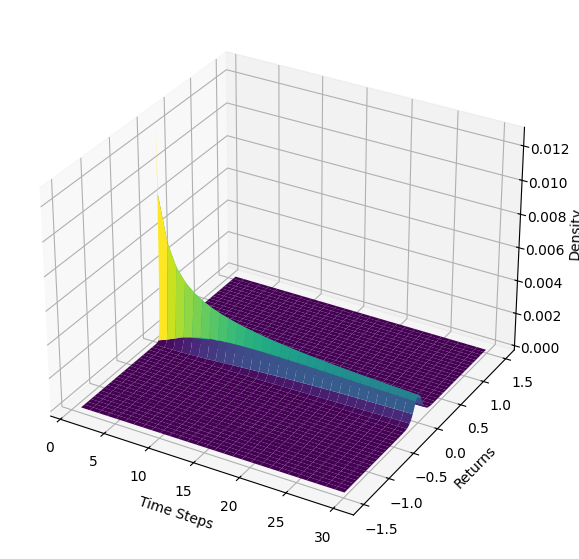

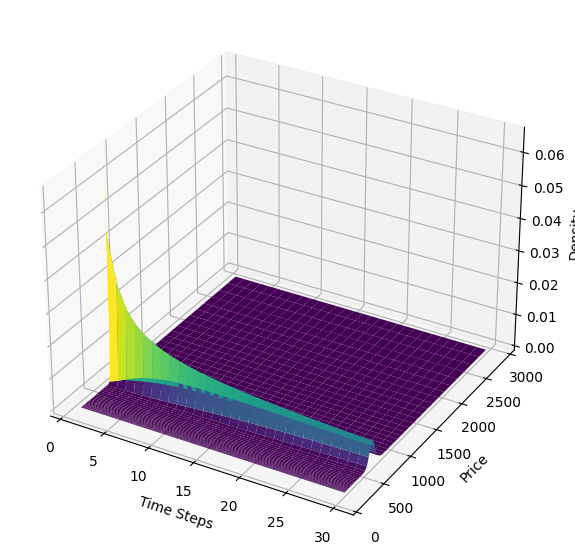

In [197]:
# Plotly and Matplotlib functions to graph the probability cones, 3D density over time, and the state classification overlay.
def plot_hmm_classification_plotly(clean_df, posterior, column_name='Close'):
    most_likely_states = np.argmax(posterior, axis=0)
    num_states = posterior.shape[0]
    colors = px.colors.qualitative.Plotly[:num_states]
    
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True, 
                        vertical_spacing=0.1, 
                        subplot_titles=("Price with HMM State Classification", "State Probabilities"))
    
    fig.add_trace(
        go.Scatter(
            x=clean_df['date'],
            y=clean_df[column_name],
            mode='lines',
            line=dict(color='lightgray', width=1.5),
            name='Price',
            showlegend=False
        ), row=1, col=1)

    for state in range(num_states):
        mask = (most_likely_states == state)
        fig.add_trace(
            go.Scatter(
                x=clean_df['date'][mask],
                y=clean_df[column_name][mask],
                mode='markers',
                marker=dict(color=colors[state], size=6),
                name=f'State {state}',
                showlegend=True 
            ), row=1, col=1)
    
    for state in range(num_states):
        fig.add_trace(
            go.Scatter(
                x=clean_df['date'],
                y=posterior[state, :],
                mode='lines',
                line=dict(color=colors[state]),
                name=f'State {state} Prob',
                showlegend=False
            ), row=2, col=1)
    
    fig.update_layout(height=800, title_text="HMM State Classification over Price", hovermode="x unified")
    fig.show()


    
def plot_historical_cones_plotly(clean_df, trained_forecast, posterior, column_name='Close'):
    lookback_days = 330
    df_recent = clean_df.tail(lookback_days).copy()
    total_len = len(clean_df)
    
    fig = go.Figure()
    
    offsets = [0, 65, 130, 195, 260] 
    forecast_horizon = 40     
    
    colors = ['rgba(255, 0, 0, 0.2)', 'rgba(0, 255, 0, 0.2)', 'rgba(0, 0, 255, 0.2)', 'rgba(255, 165, 0, 0.2)', 'rgba(128, 0, 128, 0.2)']
    lines = ['red', 'green', 'blue', 'orange', 'purple']
    
    original_compute = trained_forecast.compute_probs
    def safe_compute_probs():
        trained_forecast.probs[:, 1:] = 0.0 
        return original_compute()
    trained_forecast.compute_probs = safe_compute_probs

    for i, offset in enumerate(offsets):
        target_idx = total_len - 1 - offset
        if target_idx < 0: 
            continue
            
        S0 = float(clean_df[column_name].iloc[target_idx])
        start_date = clean_df['date'].iloc[target_idx]
        
        trained_forecast.max_T = forecast_horizon
        trained_forecast.probs = np.zeros((trained_forecast.bottom_states, forecast_horizon + 1), dtype=float)
        trained_forecast.probs[:, 0] = posterior[:, target_idx] 

        lower, upper, mid = trained_forecast.create_probability_cone(S0, confidence=0.70)
        
        cone_dates = pd.bdate_range(start=start_date + pd.Timedelta(days=1), periods=forecast_horizon)
        
        c_fill = colors[i]
        c_line = lines[i]
        
        fig.add_trace(go.Scatter(x=cone_dates, y=upper, mode='lines', line=dict(width=0), showlegend=False, hoverinfo='skip'))
        
        fig.add_trace(go.Scatter(x=cone_dates, y=lower, mode='lines', line=dict(width=0), fill='tonexty', fillcolor=c_fill, name=f'95% CI (-{offset}d)'))
        
        fig.add_trace(go.Scatter(x=cone_dates, y=mid, mode='lines', line=dict(color=c_line, width=2, dash='dot'), name=f'Median (-{offset}d)'))

    trained_forecast.compute_probs = original_compute

    fig.add_trace(go.Scatter(
        x=df_recent['date'],
        y=df_recent[column_name],
        mode='lines',
        line=dict(color='black', width=2),
        name='Actual Price'
    ))

    fig.update_layout(
        height=800, 
        title_text=f"HHMM Backtesting: 50-Day Probability Cones (Last {lookback_days} Days)", 
        xaxis_title="Date",
        yaxis_title="Price",
        hovermode="x unified"
    )
    fig.show()


def plot_3d_densities(density, x_range, T, type_name="Price"):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    time_steps = np.arange(1, T + 1)
    Y = x_range
    X, Z = np.meshgrid(time_steps, Y)
    W = np.vstack(density).T
    ax.plot_surface(X, Z, W, cmap='viridis')
    ax.set_xlabel('Time Steps')
    ax.set_ylabel(type_name)
    ax.set_zlabel('Density')
    plt.show()

# Execution of Plots

plot_hmm_classification_plotly(result_df, model_posterior, 'Close')
plot_3d_densities(forecasted_return_densities, x_returns, maxT, type_name="Returns")
plot_3d_densities(forecasted_stock_densities, x_prices, maxT, type_name="Price")
plot_historical_cones_plotly(result_df, forecast, model_posterior, 'Close')
